In [ ]:
# ============================================
# CELL 1: Setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

base_path = '/content/drive/MyDrive/capstone_project'

# Load both original and STL enhanced predictions
test_predictions_hybrid = np.load(f'{base_path}/processed_data/test_predictions.npy')
test_predictions_stl = np.load(f'{base_path}/processed_data/test_predictions_stl.npy')
test_actual = np.load(f'{base_path}/processed_data/test_actual.npy')
train_df = pd.read_csv(f'{base_path}/processed_data/train_data.csv')
test_df = pd.read_csv(f'{base_path}/processed_data/test_data.csv')
precinct_ids = np.load(f'{base_path}/processed_data/precinct_ids.npy')

CRIME_TYPES = ['assault', 'criminal_damage', 'robbery', 'theft']

print(f"✅ Test actual shape: {test_actual.shape}")
print(f"✅ Hybrid predictions shape: {test_predictions_hybrid.shape}")
print(f"✅ STL predictions shape: {test_predictions_stl.shape}")
print(f"✅ Precincts: {len(precinct_ids)}")

Mounted at /content/drive
✅ Test actual shape: (7, 49, 4)
✅ Hybrid predictions shape: (7, 49, 4)
✅ Precincts: 49


In [ ]:
# ============================================
# CELL 2: Run baseline models (Linear, Ridge, Random Forest)
# ============================================

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

FEATURE_COLS_BASELINE = ['weekend', 'holiday', 'temperature', 'humidity',
                          'wind_speed', 'precipitation']

def run_baseline(model_class, model_name, **kwargs):
    all_predictions = np.zeros_like(test_actual)

    for p_idx, pct in enumerate(precinct_ids):
        train_pct = train_df[train_df['precinct'] == pct].sort_values('date')
        test_pct = test_df[test_df['precinct'] == pct].sort_values('date')

        if len(test_pct) == 0:
            continue

        available_feats = [f for f in FEATURE_COLS_BASELINE if f in train_pct.columns and f in test_pct.columns]
        X_train = train_pct[available_feats].fillna(0).values
        X_test = test_pct[available_feats].fillna(0).values

        for c_idx, crime in enumerate(CRIME_TYPES):
            if crime not in train_pct.columns:
                continue
            y_train = train_pct[crime].values

            model = model_class(**kwargs)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            pred = np.maximum(pred, 0)

            all_predictions[:len(pred), p_idx, c_idx] = pred

    return all_predictions

print("⏳ Running Linear Regression...")
pred_lr = run_baseline(LinearRegression, "Linear Regression")
print("✅ Done")

print("⏳ Running Ridge Regression...")
pred_ridge = run_baseline(Ridge, "Ridge", alpha=1.0)
print("✅ Done")

print("⏳ Running Random Forest... (takes ~1 min)")
pred_rf = run_baseline(RandomForestRegressor, "Random Forest",
                        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
print("✅ All baselines complete!")

⏳ Running Linear Regression...
✅ Done
⏳ Running Ridge Regression...
✅ Done
⏳ Running Random Forest... (takes ~1 min)
✅ All baselines complete!


In [ ]:
# ============================================
# CELL 3: LSTM Baseline
# ============================================

class LSTMBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_layers=2, output_dim=4):
        super(LSTMBaseline, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOOKBACK = 7

# Build training crime tensor
train_dates_sorted = sorted(train_df['date'].unique())
train_crimes = np.zeros((len(train_dates_sorted), len(precinct_ids), 4))

train_indexed = train_df.set_index(['date', 'precinct'])
for d_idx, date in enumerate(train_dates_sorted):
    for p_idx, pct in enumerate(precinct_ids):
        try:
            row = train_indexed.loc[(date, pct)]
            for c_idx, crime in enumerate(CRIME_TYPES):
                train_crimes[d_idx, p_idx, c_idx] = row[crime]
        except KeyError:
            pass

pred_lstm = np.zeros_like(test_actual)

print("⏳ Training LSTM baselines... (2-3 minutes)")

for p_idx in range(len(precinct_ids)):
    series = train_crimes[:, p_idx, :]

    X, Y = [], []
    for i in range(LOOKBACK, len(series)):
        X.append(series[i-LOOKBACK:i])
        Y.append(series[i])
    X = torch.FloatTensor(np.array(X)).to(device)
    Y = torch.FloatTensor(np.array(Y)).to(device)

    lstm_model = LSTMBaseline(input_dim=4, hidden_dim=32, n_layers=1, output_dim=4).to(device)
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    lstm_model.train()
    for epoch in range(30):
        optimizer.zero_grad()
        pred = lstm_model(X)
        loss = criterion(pred, Y)
        loss.backward()
        optimizer.step()

    lstm_model.eval()
    with torch.no_grad():
        last_seq = torch.FloatTensor(train_crimes[-LOOKBACK:, p_idx, :]).unsqueeze(0).to(device)
        for t in range(test_actual.shape[0]):
            p = lstm_model(last_seq).cpu().numpy()[0]
            pred_lstm[t, p_idx, :] = np.maximum(p, 0)
            new_input = torch.FloatTensor(p).unsqueeze(0).unsqueeze(0).to(device)
            last_seq = torch.cat([last_seq[:, 1:, :], new_input], dim=1)

    if (p_idx + 1) % 10 == 0:
        print(f"  Completed {p_idx+1}/{len(precinct_ids)} precincts")

print("✅ LSTM baseline complete!")

⏳ Training LSTM baselines... (2-3 minutes)
  Completed 10/49 precincts
  Completed 20/49 precincts
  Completed 30/49 precincts
  Completed 40/49 precincts
✅ LSTM baseline complete!


In [ ]:
# ============================================
# CELL 4: Compute MAE, RMSE, R² for all models
# Note: Informer+ST-GCN + STL is our final novel model
# ============================================

def compute_metrics(actual, predicted, crime_types):
    results = {}
    for c_idx, crime in enumerate(crime_types):
        y_true = actual[:, :, c_idx].flatten()
        y_pred = predicted[:, :, c_idx].flatten()
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        results[crime] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 2)}
    return results

models = {
    'Linear Regression': pred_lr,
    'Ridge Regression': pred_ridge,
    'Random Forest': pred_rf,
    'LSTM': pred_lstm,
    'Informer+ST-GCN': test_predictions_hybrid,
    'Informer+ST-GCN + STL (Ours)': test_predictions_stl,
}

print("=" * 85)
print("RESULTS COMPARISON — ALL MODELS")
print("=" * 85)

all_results = {}
for model_name, predictions in models.items():
    metrics = compute_metrics(test_actual, predictions, CRIME_TYPES)
    all_results[model_name] = metrics
    print(f"\n📊 {model_name}:")
    for crime, vals in metrics.items():
        print(f"   {crime:20s} | MAE: {vals['MAE']:6.2f} | RMSE: {vals['RMSE']:6.2f} | R²: {vals['R2']:6.2f}")

print("\n" + "=" * 85)

RESULTS COMPARISON — ALL MODELS

📊 Linear Regression:
   assault              | MAE:   1.53 | RMSE:   2.11 | R²:   0.41
   criminal_damage      | MAE:   1.45 | RMSE:   3.68 | R²:   0.13
   robbery              | MAE:   0.60 | RMSE:   0.83 | R²:   0.23
   theft                | MAE:   1.80 | RMSE:   2.36 | R²:   0.51

📊 Ridge Regression:
   assault              | MAE:   1.53 | RMSE:   2.11 | R²:   0.41
   criminal_damage      | MAE:   1.45 | RMSE:   3.69 | R²:   0.13
   robbery              | MAE:   0.60 | RMSE:   0.83 | R²:   0.23
   theft                | MAE:   1.80 | RMSE:   2.36 | R²:   0.51

📊 Random Forest:
   assault              | MAE:   1.58 | RMSE:   2.21 | R²:   0.35
   criminal_damage      | MAE:   1.72 | RMSE:   5.30 | R²:  -0.80
   robbery              | MAE:   0.62 | RMSE:   0.84 | R²:   0.21
   theft                | MAE:   1.83 | RMSE:   2.39 | R²:   0.50

📊 LSTM:
   assault              | MAE:   2.47 | RMSE:   3.53 | R²:  -0.65
   criminal_damage      | MAE:   1.83 | 

In [ ]:
# ============================================
# CELL 5: Create formatted results tables (like parent paper Tables 2-5)
# ============================================

for crime in CRIME_TYPES:
    print(f"\n{'='*65}")
    print(f"  TABLE: Model Comparison — {crime.replace('_',' ').upper()}")
    print(f"{'='*65}")
    print(f"  {'Model':<35} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
    print(f"  {'-'*61}")
    for model_name in models.keys():
        m = all_results[model_name][crime]
        marker = ' *' if 'STL (Ours)' in model_name else ''
        print(f"  {model_name:<35} {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['R2']:>8.2f}{marker}")

# Save results to CSV
results_df_list = []
for model_name, metrics in all_results.items():
    for crime, vals in metrics.items():
        results_df_list.append({
            'Model': model_name,
            'Crime Type': crime,
            'MAE': vals['MAE'],
            'RMSE': vals['RMSE'],
            'R2': vals['R2']
        })

results_df = pd.DataFrame(results_df_list)
results_df.to_csv(f'{base_path}/outputs/model_comparison_results.csv', index=False)
print(f"\n✅ Results saved to: outputs/model_comparison_results.csv")


  TABLE: Model Comparison — ASSAULT
  Model                               MAE     RMSE       R²
  --------------------------------------------------------
  Linear Regression                  1.53     2.11     0.41
  Ridge Regression                   1.53     2.11     0.41
  Random Forest                      1.58     2.21     0.35
  LSTM                               2.47     3.53    -0.65
  Our Model (Informer+ST-GCN)        1.62     2.28     0.31 *

  TABLE: Model Comparison — CRIMINAL DAMAGE
  Model                               MAE     RMSE       R²
  --------------------------------------------------------
  Linear Regression                  1.45     3.68     0.13
  Ridge Regression                   1.45     3.69     0.13
  Random Forest                      1.72     5.30    -0.80
  LSTM                               1.83     4.23    -0.15
  Our Model (Informer+ST-GCN)        1.53     3.67     0.14 *

  TABLE: Model Comparison — ROBBERY
  Model                               M

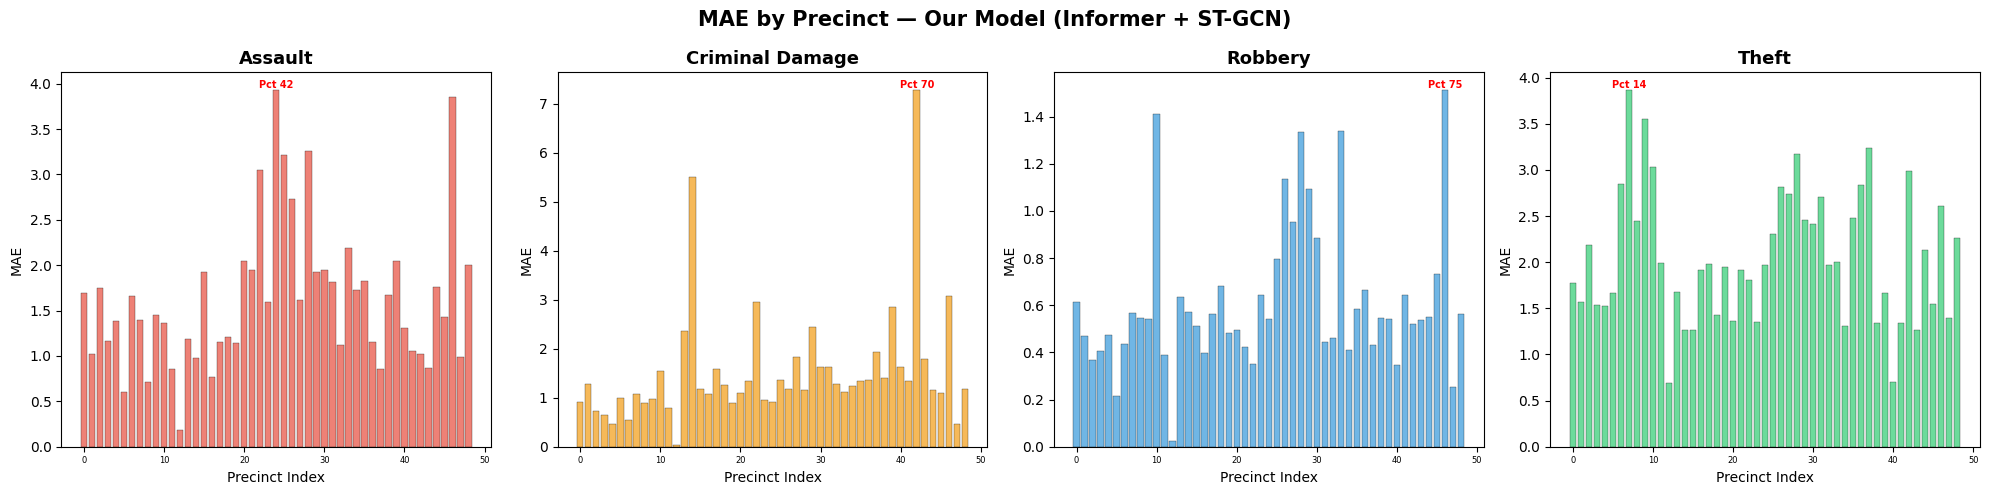

✅ Saved: mae_by_precinct.png


In [ ]:
# ============================================
# CELL 6: Spatial distribution of MAE per precinct
# Using our final model (Informer + ST-GCN + STL)
# (Like Figure 3 in parent paper)
# ============================================
colors_plot = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for c_idx, crime in enumerate(CRIME_TYPES):
    ax = axes[c_idx]
    mae_per_precinct = np.mean(np.abs(test_actual[:, :, c_idx] - test_predictions_stl[:, :, c_idx]), axis=0)

    bars = ax.bar(range(len(precinct_ids)), mae_per_precinct, color=colors_plot[c_idx], alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{crime.replace("_", " ").title()}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Precinct Index')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', labelsize=6)

    # Mark the worst precinct
    worst = np.argmax(mae_per_precinct)
    ax.annotate(f'Pct {precinct_ids[worst]}', xy=(worst, mae_per_precinct[worst]),
                fontsize=7, ha='center', va='bottom', color='red', fontweight='bold')

plt.suptitle('MAE by Precinct — Our Final Model (Informer + ST-GCN + STL)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/mae_by_precinct.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: mae_by_precinct.png")

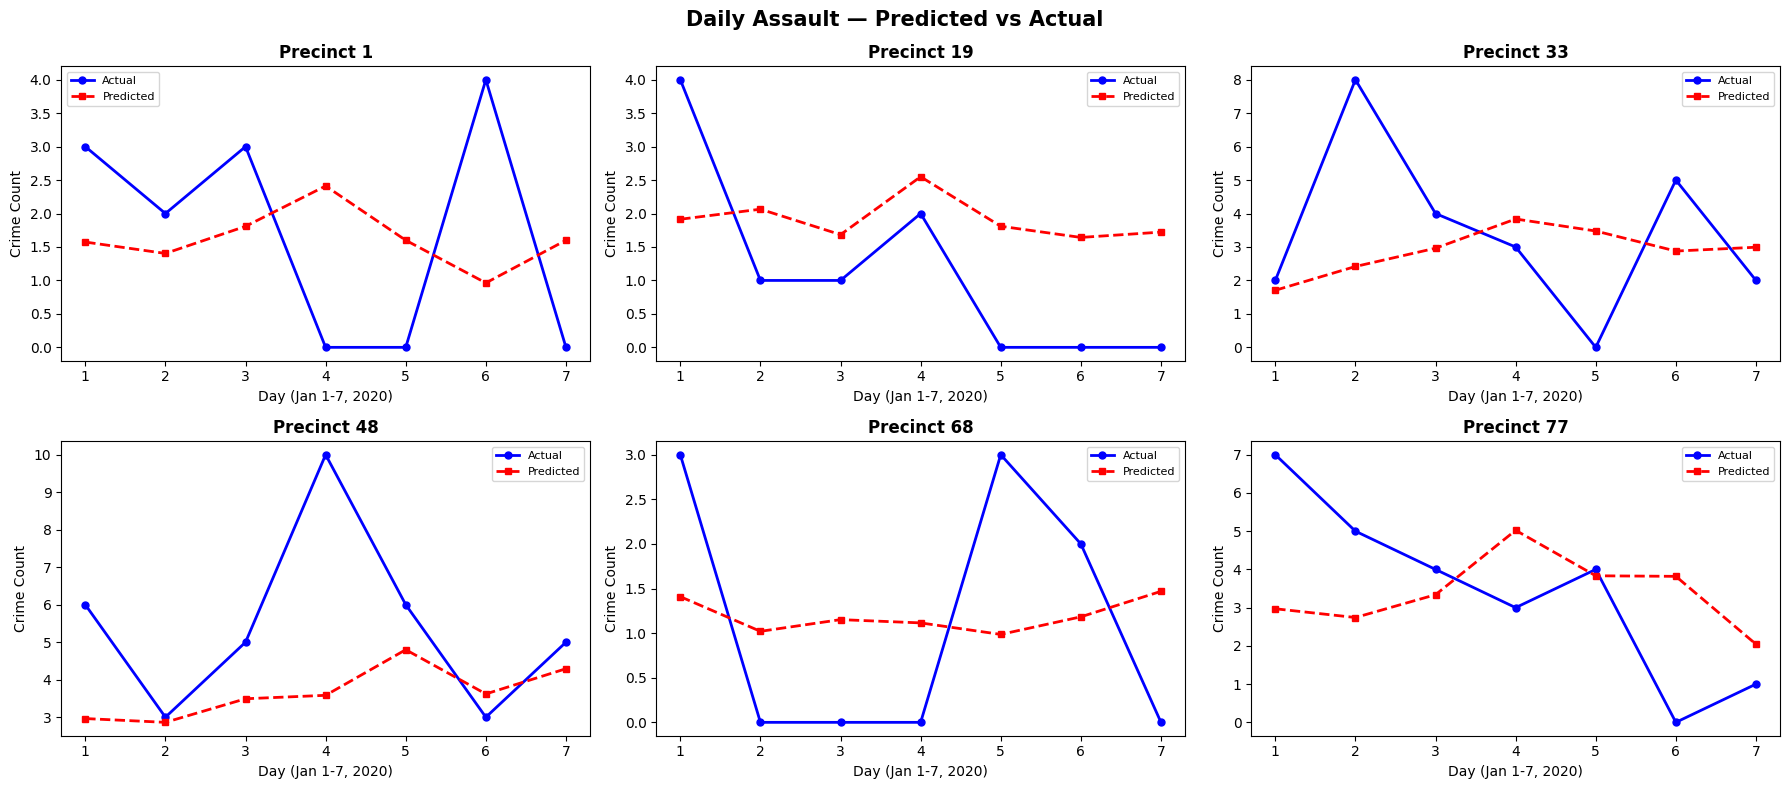

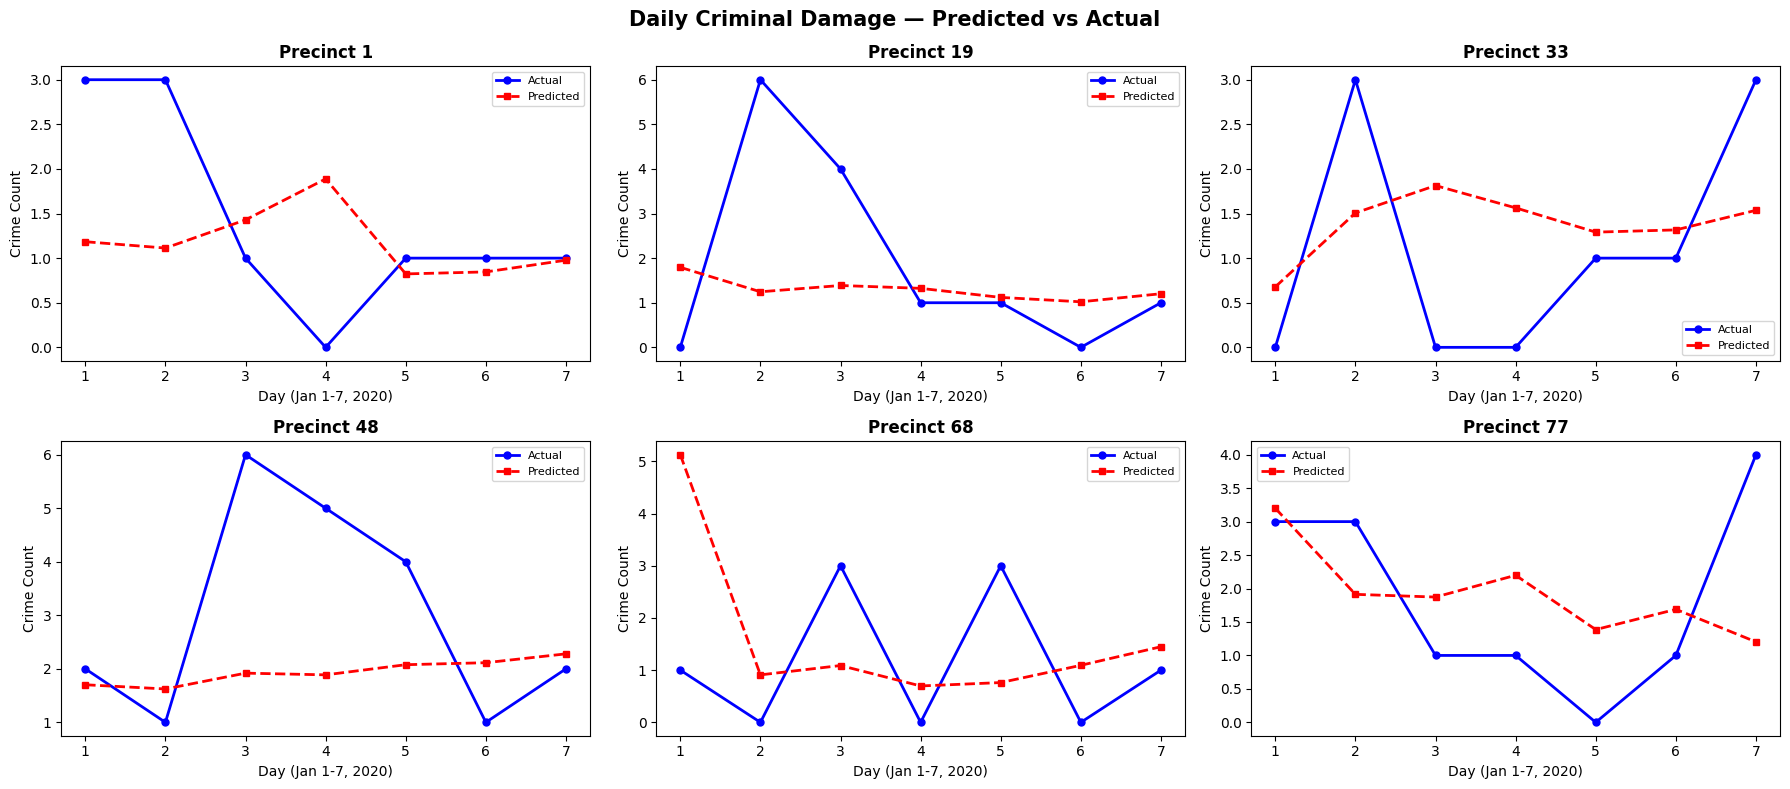

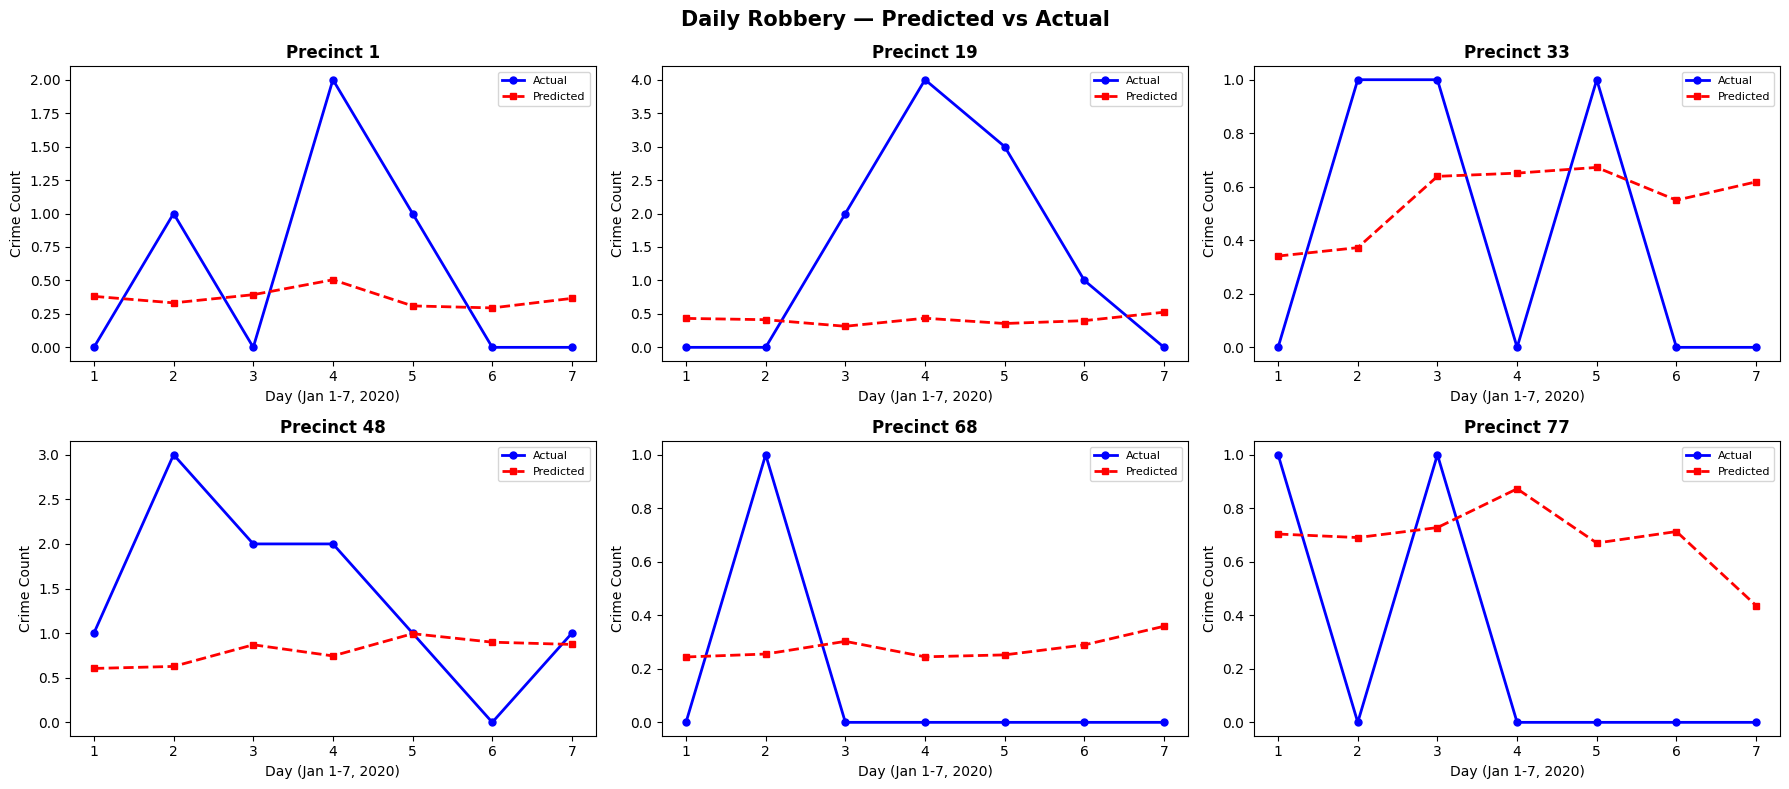

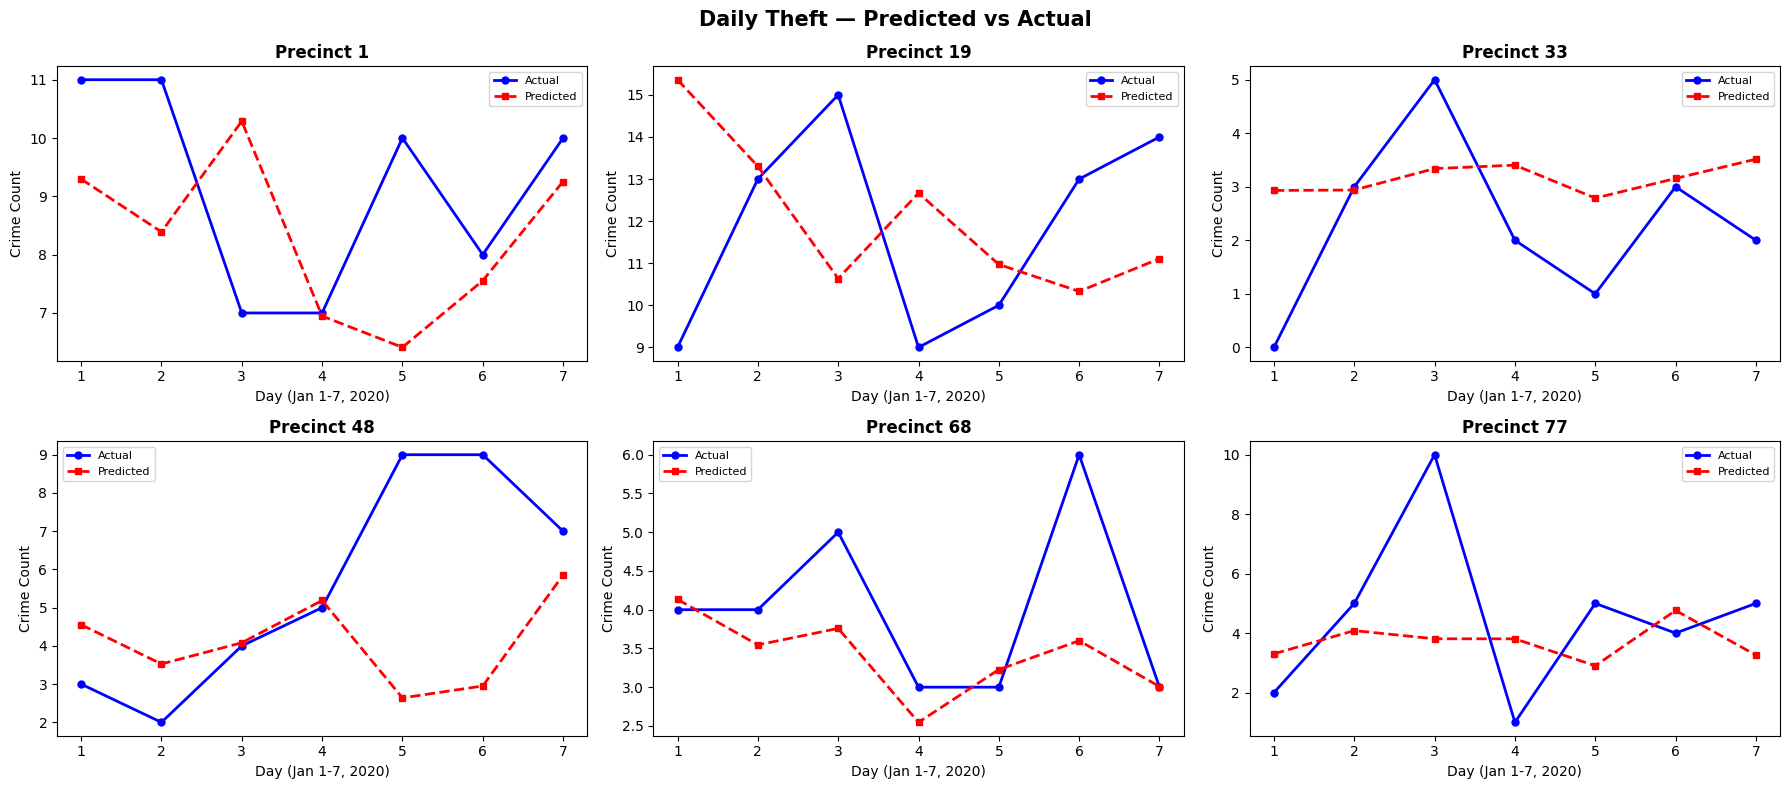

✅ All time series plots saved!


In [ ]:
# ============================================
# CELL 7: Predicted vs Actual for sample precincts
# Using our final model (Informer + ST-GCN + STL)
# (Like Figure 5 in parent paper)
# ============================================

sample_indices = [0, 10, 20, 30, 40, 48] if len(precinct_ids) > 48 else list(range(min(6, len(precinct_ids))))

for crime_idx, crime in enumerate(CRIME_TYPES):
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for idx, p_idx in enumerate(sample_indices):
        if idx >= 6:
            break
        ax = axes[idx]
        actual = test_actual[:, p_idx, crime_idx]
        predicted = test_predictions_stl[:, p_idx, crime_idx]

        days = range(1, len(actual) + 1)
        ax.plot(days, actual, 'b-o', label='Actual', markersize=5, linewidth=2)
        ax.plot(days, predicted, 'r--s', label='Predicted (STL)', markersize=5, linewidth=2)
        ax.set_title(f'Precinct {precinct_ids[p_idx]}', fontweight='bold')
        ax.set_xlabel('Day (Jan 1-7, 2020)')
        ax.set_ylabel('Crime Count')
        ax.legend(fontsize=8)
        ax.set_xticks(range(1, 8))

    plt.suptitle(f'Daily {crime.replace("_"," ").title()} — Predicted vs Actual (Our Final Model: Informer + ST-GCN + STL)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{base_path}/outputs/timeseries_{crime}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ All time series plots saved!")

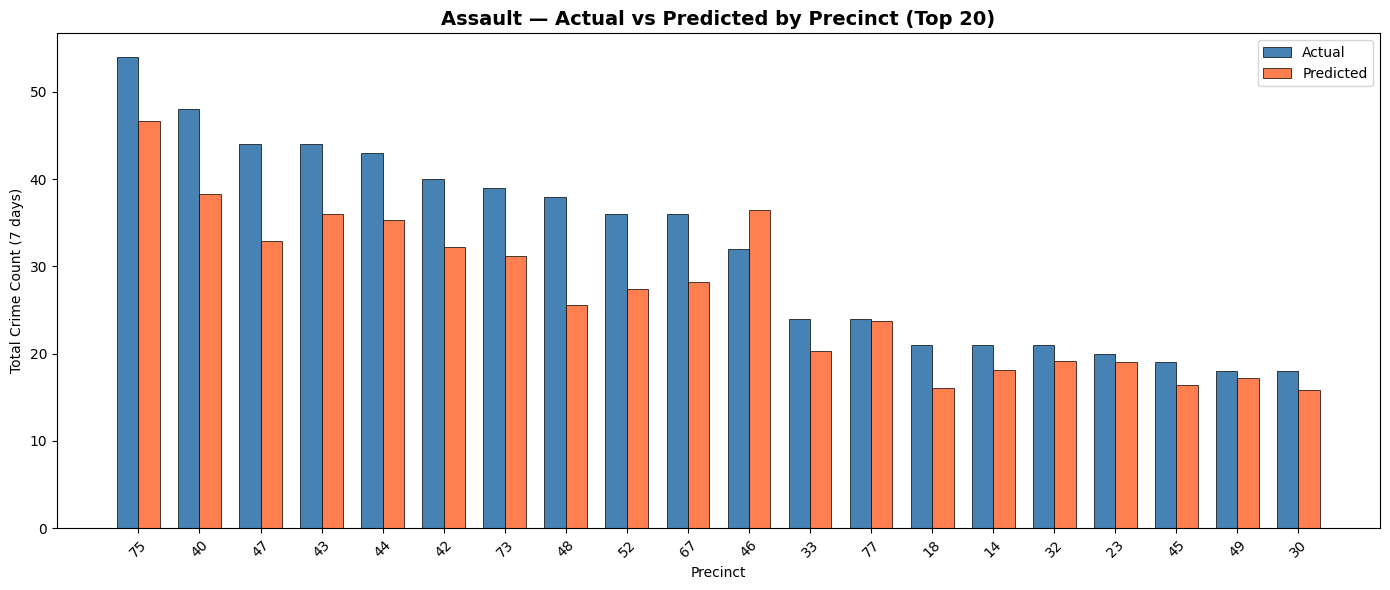

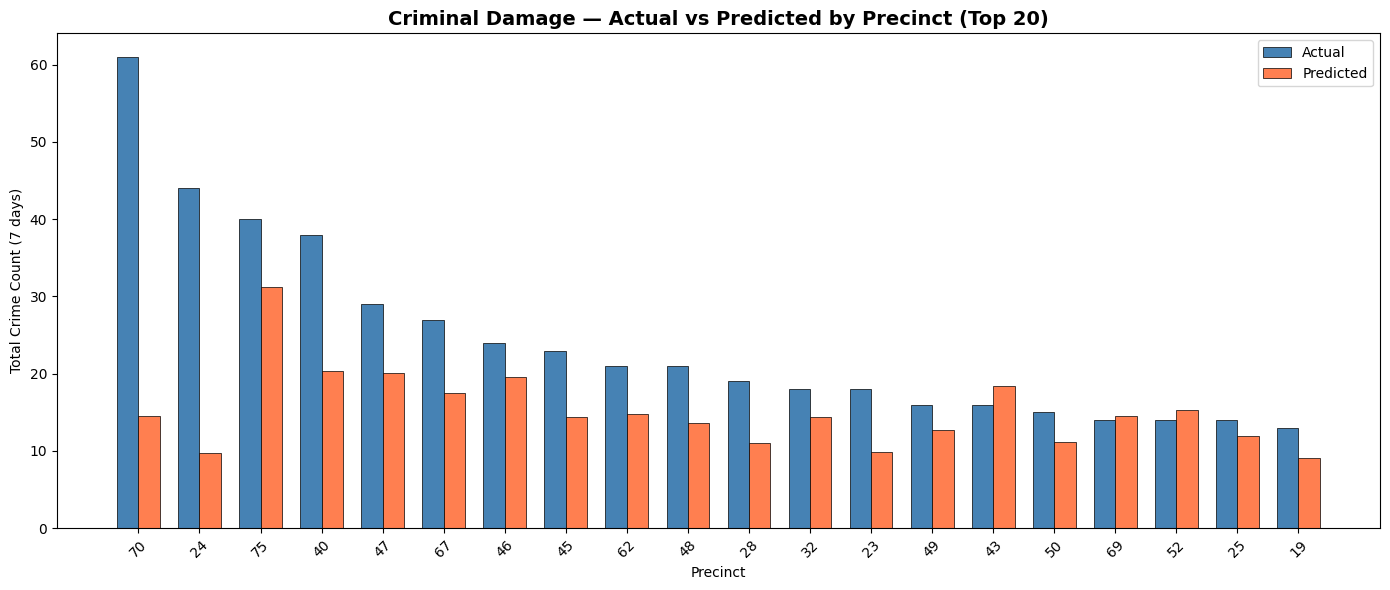

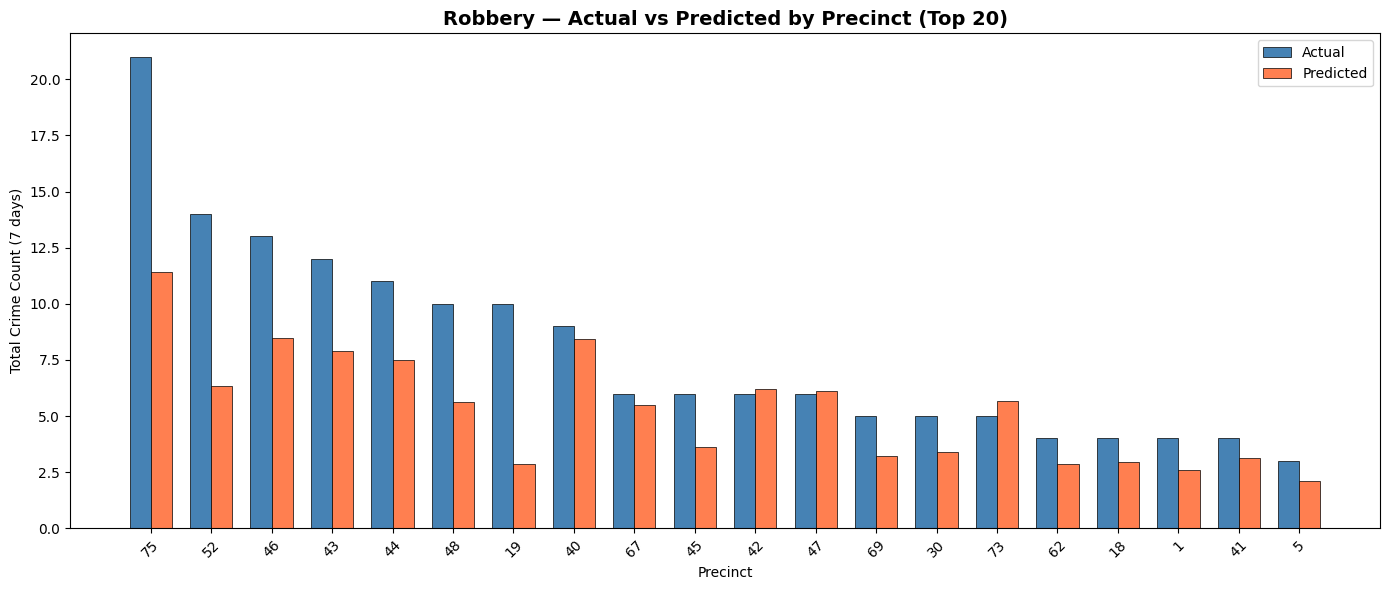

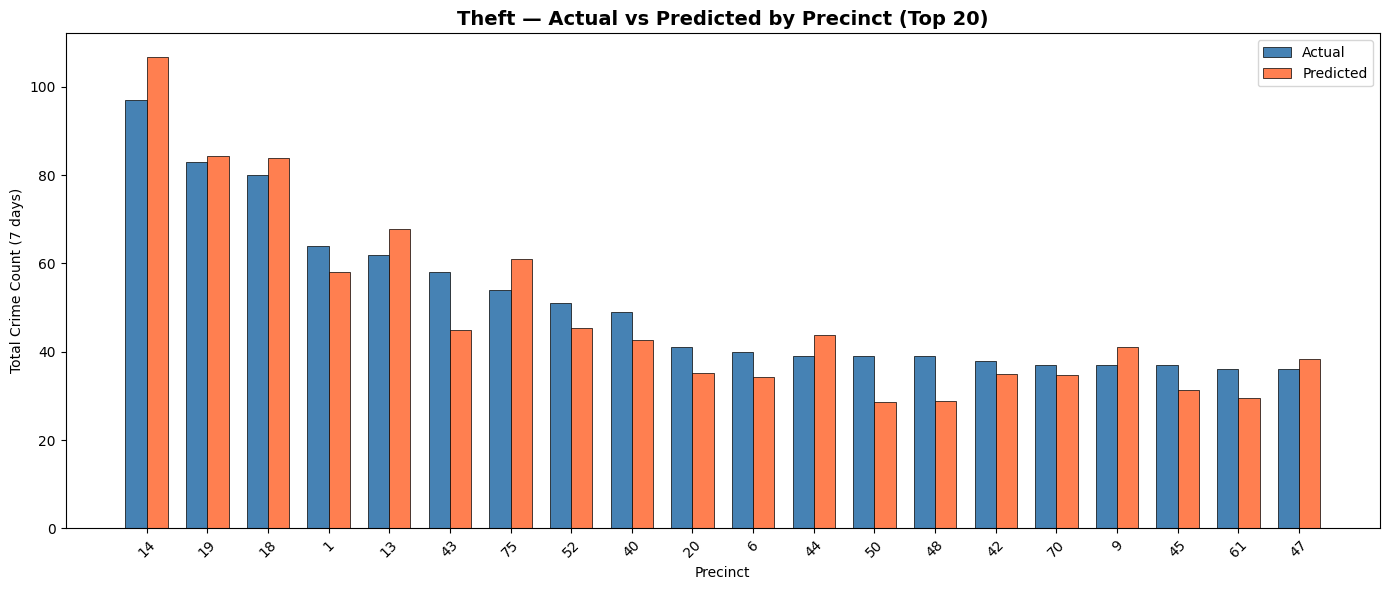

✅ All bar charts saved!


In [ ]:
# ============================================
# CELL 8: Predicted vs Actual totals by precinct
# Using our final model (Informer + ST-GCN + STL)
# (Like Figure 4 in parent paper)
# ============================================

for crime_idx, crime in enumerate(CRIME_TYPES):
    actual_totals = test_actual[:, :, crime_idx].sum(axis=0)
    pred_totals = test_predictions_stl[:, :, crime_idx].sum(axis=0)

    sort_idx = np.argsort(actual_totals)[::-1][:20]

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(sort_idx))
    width = 0.35
    ax.bar(x - width/2, actual_totals[sort_idx], width, label='Actual', color='steelblue', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, pred_totals[sort_idx], width, label='Predicted (STL)', color='coral', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Precinct')
    ax.set_ylabel('Total Crime Count (7 days)')
    ax.set_title(f'{crime.replace("_"," ").title()} — Actual vs Predicted by Precinct (Top 20)\nOur Final Model: Informer + ST-GCN + STL',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(precinct_ids[i]) for i in sort_idx], rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{base_path}/outputs/barchart_{crime}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ All bar charts saved!")

In [ ]:
# ============================================
# CELL 9: Summary of all outputs
# ============================================
import os

output_path = f'{base_path}/outputs'
files = sorted(os.listdir(output_path))

print("=" * 50)
print("📁 ALL FILES IN YOUR outputs/ FOLDER")
print("=" * 50)
for f in files:
    size = os.path.getsize(f'{output_path}/{f}') / 1024
    print(f"  📄 {f:40s} ({size:.0f} KB)")

print(f"\n✅ Total files: {len(files)}")

📁 ALL FILES IN YOUR outputs/ FOLDER
  📄 adjacency_graph.png                      (844 KB)
  📄 barchart_assault.png                     (56 KB)
  📄 barchart_criminal_damage.png             (59 KB)
  📄 barchart_robbery.png                     (60 KB)
  📄 barchart_theft.png                       (56 KB)
  📄 correlation_heatmap.png                  (177 KB)
  📄 crime_by_type.png                        (49 KB)
  📄 crime_over_time.png                      (585 KB)
  📄 day_of_week.png                          (80 KB)
  📄 mae_by_precinct.png                      (69 KB)
  📄 model_comparison_results.csv             (1 KB)
  📄 monthly_seasonality.png                  (123 KB)
  📄 timeseries_assault.png                   (217 KB)
  📄 timeseries_criminal_damage.png           (209 KB)
  📄 timeseries_robbery.png                   (208 KB)
  📄 timeseries_theft.png                     (220 KB)
  📄 top_precincts.png                        (75 KB)
  📄 training_loss.png                        (34 KB)

✅ 